# Exploratory Data Analysis

- Data source: https://www.kaggle.com/datasets/tunguz/bank-marketing-data-set
- Artigo: https://sci-hub.box/10.1016/j.dss.2014.03.001

## 0. Configs

### 0.1 Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
import numpy as np
import warnings

## dataviz
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# funções utils
from utils_eda import column_descriptions, miss_cat_pd, cont_perc_categorias, grafico_barras, months, days, grafico_yes_no

# configurações de exibição
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

%matplotlib inline

### 0.2 Data

In [70]:
df1 = pd.read_csv('data/bank-marketing-data-set/bank-additional-full.csv', sep = ';')
df1['month'] = df1['month'].map(months)
df1['day_of_week'] = df1['day_of_week'].map(days)

df1.columns = [c.replace('.', '_') for c in df1.columns]

df2 = pd.read_csv('data/bank-marketing-data-set/bank-full.csv', sep = ';')

print(f"Tamanho do dataset 1 (dados de maio/2008 a novembro/2010): {df1.shape}")
print(f"Tamanho do dataset 2 (versão mais antiga do dataset):      {df2.shape}")

Tamanho do dataset 1 (dados de maio/2008 a novembro/2010): (41188, 21)
Tamanho do dataset 2 (versão mais antiga do dataset):      (45211, 17)


In [71]:
df1.head(3)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,05. may,1. mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,05. may,1. mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,05. may,1. mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
df2.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### 0.3 Nulls e número de categorias

In [ ]:
df_cats = miss_cat_pd(df1).rename(columns = {'perc_missings':'perc_missings_df1', 'n_categorias':'n_categorias_df1'})\
    .merge(miss_cat_pd(df2).rename(columns = {'perc_missings':'perc_missings_df2', 'n_categorias':'n_categorias_df2'}),
           on = ['coluna'], how = 'outer')
           
df_cats['description'] = df_cats['coluna'].map(column_descriptions)

with pd.option_context('display.max_colwidth', None):
    display(df_cats[['coluna', 'description', 'perc_missings_df1', 'perc_missings_df2', 'n_categorias_df1', 'n_categorias_df2']].sort_values('n_categorias_df2'))


,coluna,description,perc_missings_df1,perc_missings_df2,n_categorias_df1,n_categorias_df2
13,housing,Has housing loan,0.0,0.0,3.0,2.0
15,loan,Has personal loan,0.0,0.0,3.0,2.0
8,default,Has credit in default,0.0,0.0,3.0,2.0
22,y,Whether the client subscribed to a term deposit,0.0,0.0,2.0,2.0
16,marital,Marital status,0.0,0.0,4.0,3.0
5,contact,Contact communication type,0.0,0.0,2.0,3.0
10,education,Education level,0.0,0.0,8.0,4.0
20,poutcome,Outcome of the previous marketing campaign,0.0,0.0,3.0,4.0
14,job,Type of job,0.0,0.0,12.0,12.0
17,month,Last contact month of year,0.0,0.0,10.0,12.0


## 1. Distribuições monovariadas

### Age

In [16]:
display(df1[['age']].describe(percentiles = [i/20 for i in range(20)]).T)

,count,mean,std,min,0%,5%,10%,15%,20%,25%,30%,35%,40%,45%,50%,55%,60%,65%,70%,75%,80%,85%,90%,95%,max
age,41188.0,40.02406,10.42125,17.0,17.0,26.0,28.0,30.0,31.0,32.0,33.0,34.0,35.0,37.0,38.0,40.0,41.0,43.0,45.0,47.0,49.0,52.0,55.0,58.0,98.0


In [5]:
fig = px.histogram(df1, x = 'age', marginal = 'box')
fig.show()

### Job

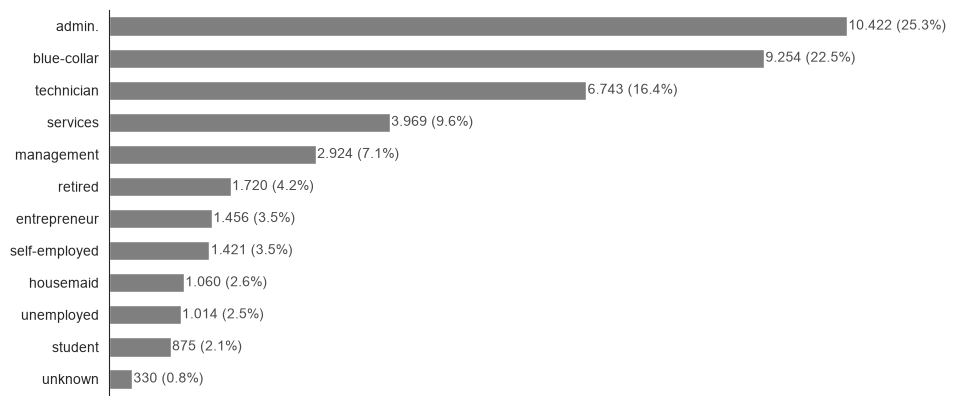

In [21]:
grafico_barras(df_ = df1, coluna = 'job', figsize = (10, 5), sort_categorias = False, casas_decimais = 1, espessura_barras = 0.6)

### Marital

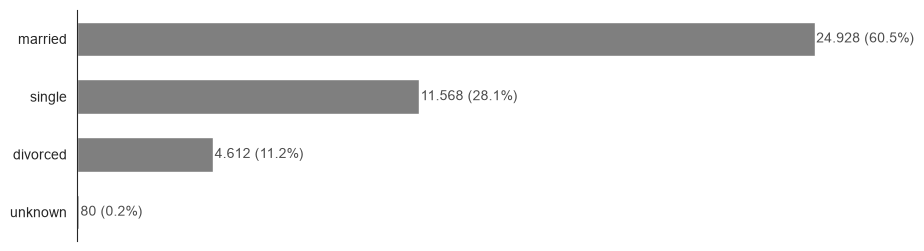

In [20]:
grafico_barras(df_ = df1, coluna = 'marital', figsize = (10, 3), sort_categorias = False, casas_decimais = 1, espessura_barras = 0.6)

- Remover unknown?

### Education

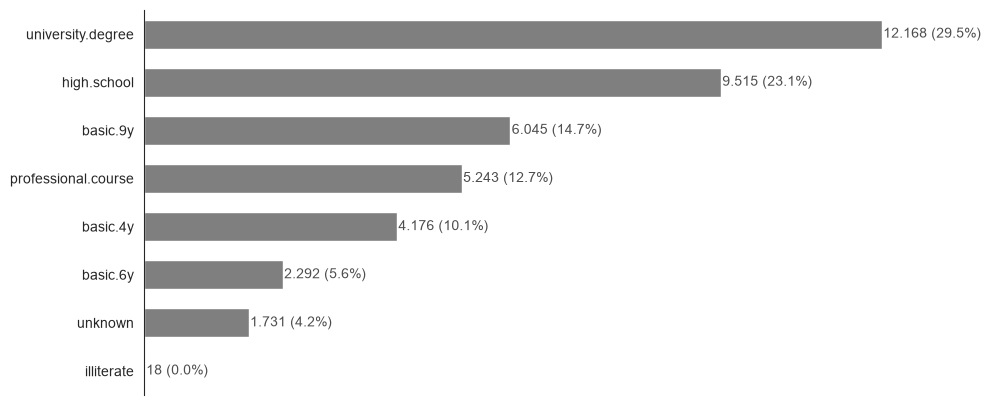

In [ ]:
grafico_barras(df_ = df1, coluna = 'education', figsize = (10, 5), sort_categorias = False, casas_decimais = 1, espessura_barras = 0.6)

### Default (se tem crédito como padrão)

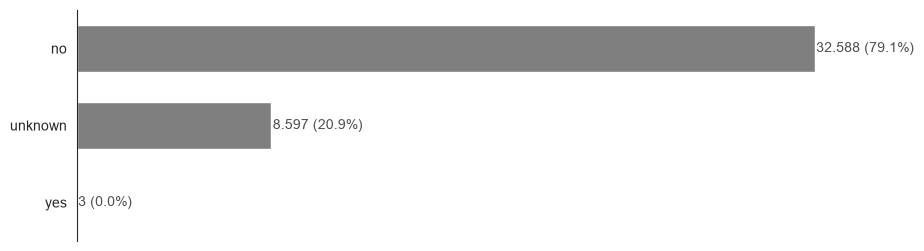

In [23]:
grafico_barras(df_ = df1, coluna = 'default', figsize = (10, 3), sort_categorias = False, casas_decimais = 1, espessura_barras = 0.6)

### Housing (se tem financiamento imobiliário)

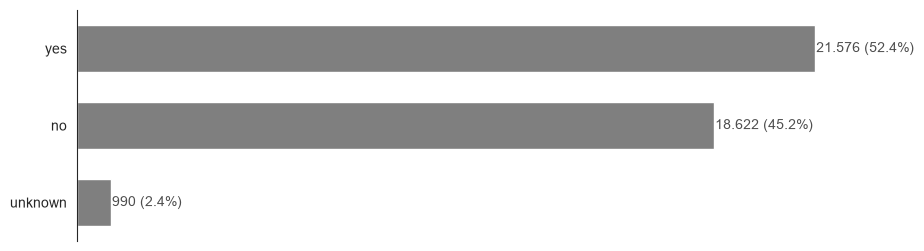

In [24]:
grafico_barras(df_ = df1, coluna = 'housing', figsize = (10, 3), sort_categorias = False, casas_decimais = 1, espessura_barras = 0.6)

### Loan (se tem empréstimo pessoal)

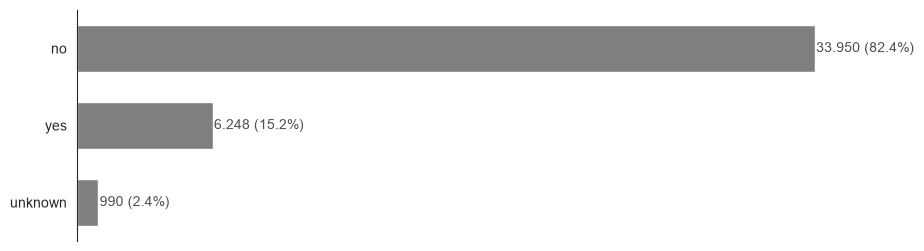

In [25]:
grafico_barras(df_ = df1, coluna = 'loan', figsize = (10, 3), sort_categorias = False, casas_decimais = 1, espessura_barras = 0.6)

### Contact

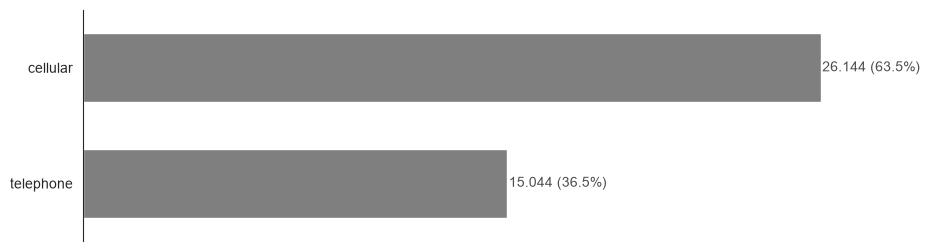

In [27]:
grafico_barras(df_ = df1, coluna = 'contact', figsize = (10, 3), sort_categorias = False, casas_decimais = 1, espessura_barras = 0.6)

### Month

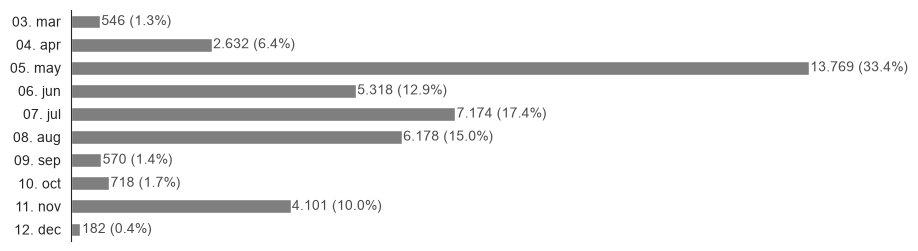

In [35]:
grafico_barras(df_ = df1, coluna = 'month', figsize = (10, 3), sort_categorias = True, casas_decimais = 1, espessura_barras = 0.6)

### Day of week

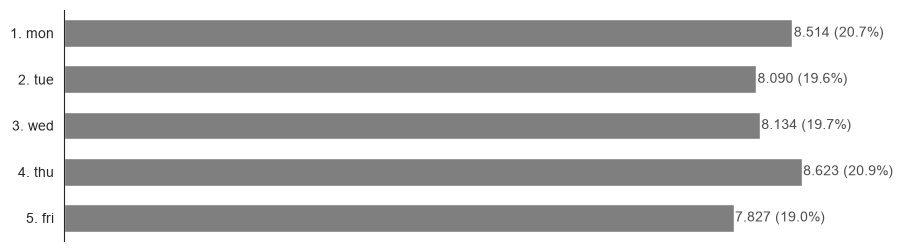

In [39]:
grafico_barras(df_ = df1, coluna = 'day_of_week', figsize = (10, 3), sort_categorias = True, casas_decimais = 1, espessura_barras = 0.6)


### Duration (duração da última ligacão em segundos)

In [46]:
print(f"Describe em segundos\n{'-' * 100}")
display((df1['duration']).describe(percentiles = [i/10 for i in range(10)]).round(2).reset_index().set_index('index').T)

print(f"Describe em minutos\n{'-' * 100}")
display((df1['duration'] / 60).describe(percentiles = [i/10 for i in range(10)]).round(2).reset_index().set_index('index').T)

Describe em segundos
----------------------------------------------------------------------------------------------------


index,count,mean,std,min,0%,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
duration,41188.0,258.29,259.28,0.0,0.0,59.0,89.0,116.0,146.0,180.0,222.0,280.0,368.0,551.0,4918.0


Describe em minutos
----------------------------------------------------------------------------------------------------


index,count,mean,std,min,0%,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
duration,41188.0,4.3,4.32,0.0,0.0,0.98,1.48,1.93,2.43,3.0,3.7,4.67,6.13,9.18,81.97


In [13]:
fig = px.histogram(df1, x = 'duration', marginal = 'box')
fig.show()

### Campaign (número de contatos com o cliente durante a campanha)

In [50]:
display(df1[['campaign']].describe(percentiles = [i/20 for i in range(20)]).T)

,count,mean,std,min,0%,5%,10%,15%,20%,25%,30%,35%,40%,45%,50%,55%,60%,65%,70%,75%,80%,85%,90%,95%,max
campaign,41188.0,2.567593,2.770014,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,3.0,4.0,5.0,7.0,56.0


In [49]:
fig = px.histogram(df1, x = 'campaign', marginal = 'box')
fig.show()

### Pdays (quandos dias passaram desde que o cliente foi contatado desde a última campanha)

In [131]:
display(df1[['pdays']].describe(percentiles = [i/20 for i in range(20)]).T)

,count,mean,std,min,0%,5%,10%,15%,20%,25%,30%,35%,40%,45%,50%,55%,60%,65%,70%,75%,80%,85%,90%,95%,max
pdays,41188.0,962.475454,186.910907,0.0,0.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0


In [132]:
df1[['pdays']].value_counts()

pdays
999      39673
3          439
6          412
4          118
9           64
2           61
7           60
12          58
10          52
5           46
13          36
11          28
1           26
15          24
14          20
8           18
0           15
16          11
17           8
18           7
22           3
19           3
21           2
25           1
26           1
27           1
20           1
Name: count, dtype: int64

### Previous (número de contatos a este cliente antes da campanha)

In [56]:
display(df1[['previous']].describe(percentiles = [i/20 for i in range(20)]).T)

,count,mean,std,min,0%,5%,10%,15%,20%,25%,30%,35%,40%,45%,50%,55%,60%,65%,70%,75%,80%,85%,90%,95%,max
previous,41188.0,0.172963,0.494901,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,7.0


In [134]:
df1['previous'].value_counts(normalize = True)

previous
0    0.863431
1    0.110736
2    0.018306
3    0.005244
4    0.001700
5    0.000437
6    0.000121
7    0.000024
Name: proportion, dtype: float64

### Poutcome (resultado da campanha de marketing anterior)

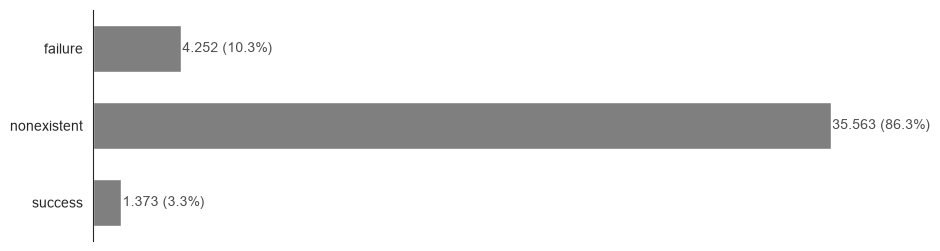

In [ ]:
grafico_barras(df_ = df1, coluna = 'poutcome', figsize = (10, 3), sort_categorias = True, casas_decimais = 1, espessura_barras = 0.6)

### Emp.var.rate (indicador trimestral de taxa de variação de emprego)

In [58]:
df1[['emp.var.rate']].value_counts()

emp.var.rate
 1.4            16234
-1.8             9184
 1.1             7763
-0.1             3683
-2.9             1663
-3.4             1071
-1.7              773
-1.1              635
-3.0              172
-0.2               10
Name: count, dtype: int64

In [136]:
print(df1['emp_var_rate'].min())
print(df1['emp_var_rate'].max())

-3.4
1.4


### Cons.price.idx (indicador mensal do índice de preço ao consumidor)

In [59]:
df1[['cons.price.idx']].value_counts()

cons.price.idx
93.994            7763
93.918            6685
92.893            5794
93.444            5175
94.465            4374
93.200            3616
93.075            2458
92.201             770
92.963             715
92.431             447
92.649             357
94.215             311
94.199             303
92.843             282
92.379             267
93.369             264
94.027             233
94.055             229
93.876             212
94.601             204
92.469             178
93.749             174
92.713             172
94.767             128
93.798              67
92.756              10
Name: count, dtype: int64

In [137]:
print(df1['cons_price_idx'].min())
print(df1['cons_price_idx'].max())

92.201
94.767


### Cons.conf.idx (indicador mensal do índice de confiança do consumidor)

In [60]:
df1[['cons.conf.idx']].value_counts()

cons.conf.idx
-36.4            7763
-42.7            6685
-46.2            5794
-36.1            5175
-41.8            4374
-42.0            3616
-47.1            2458
-31.4             770
-40.8             715
-26.9             447
-30.1             357
-40.3             311
-37.5             303
-50.0             282
-29.8             267
-34.8             264
-38.3             233
-39.8             229
-40.0             212
-49.5             204
-33.6             178
-34.6             174
-33.0             172
-50.8             128
-40.4              67
-45.9              10
Name: count, dtype: int64

In [138]:
print(df1['cons_conf_idx'].min())
print(df1['cons_conf_idx'].max())

-50.8
-26.9


### Euribor3m (indicador diário da taxa de 3 meses do índice euribor)

In [61]:
df1[['euribor3m']].value_counts()

euribor3m
4.857        2868
4.962        2613
4.963        2487
4.961        1902
4.856        1210
             ... 
0.969           1
0.933           1
0.956           1
1.045           1
1.047           1
Name: count, Length: 316, dtype: int64

In [141]:
print(df1['euribor3m'].min())
print(df1['euribor3m'].max())
print(df1['euribor3m'].mean())

0.634
5.045
3.6212908128581147


### Nr.employed (indicador quaternário do número de empregados)

In [62]:
df1[['nr.employed']].value_counts()

nr.employed
5228.1         16234
5099.1          8534
5191.0          7763
5195.8          3683
5076.2          1663
5017.5          1071
4991.6           773
5008.7           650
4963.6           635
5023.5           172
5176.3            10
Name: count, dtype: int64

In [142]:
print(df1['nr_employed'].min())
print(df1['nr_employed'].max())

4963.6
5228.1


### y

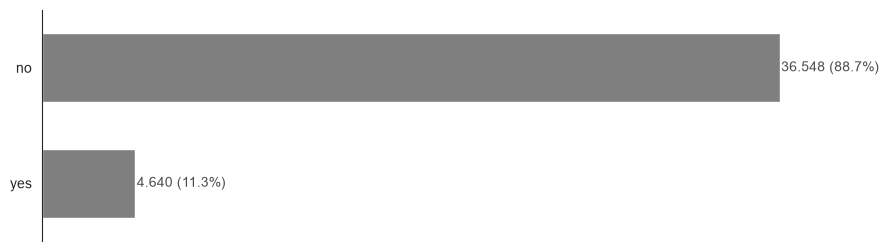

In [64]:
grafico_barras(df_ = df1, coluna = 'y', figsize = (10, 3), sort_categorias = True, casas_decimais = 1, espessura_barras = 0.6)

In [15]:
df1.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Distribuições bivariadas

### Quando uma variável é unknown, as outras também são?

In [100]:
tb_unknown = pd.DataFrame()

for c in df1.columns:
    tmp = df1[df1[c] == 'unknown']
    if tmp.shape[0] == 0:
        continue
    else:
        df_tmp = pd.DataFrame(data = {'coluna':[c], 'volume':[tmp.shape[0]], 'pct':[round(tmp.shape[0] * 100 / df1.shape[0], 2)]})

        tb_unknown = pd.concat([tb_unknown, df_tmp])

print(f"Variáveis com a categoria 'unknown'\n{'-' * 50}")
tb_unknown

Variáveis com a categoria 'unknown'
--------------------------------------------------


,coluna,volume,pct
0,job,330,0.80
0,marital,80,0.19
0,education,1731,4.20
0,default,8597,20.87
0,housing,990,2.40
0,loan,990,2.40


In [66]:
pd.crosstab(df1['job'], df1['marital'])

marital,divorced,married,single,unknown
job,,,,
admin.,1280,5253,3875,14
blue-collar,728,6687,1825,14
entrepreneur,179,1071,203,3
housemaid,161,777,119,3
management,331,2089,501,3
retired,348,1274,93,5
self-employed,133,904,379,5
services,532,2294,1137,6
student,9,41,824,1


- Para job + marital, o unknown nem sempre dá match

In [67]:
pd.crosstab(df1['housing'], df1['loan'])

loan,no,unknown,yes
housing,,,
no,16065,0,2557
unknown,0,990,0
yes,17885,0,3691


- Housing e loan tem o mesmo volume de unknown, e de fato ocorre para as mesmas entradas

In [68]:
pd.crosstab(df1['job'], df1['education'])

education,basic.4y,basic.6y,basic.9y,high.school,illiterate,professional.course,university.degree,unknown
job,,,,,,,,
admin.,77,151,499,3329,1,363,5753,249
blue-collar,2318,1426,3623,878,8,453,94,454
entrepreneur,137,71,210,234,2,135,610,57
housemaid,474,77,94,174,1,59,139,42
management,100,85,166,298,0,89,2063,123
retired,597,75,145,276,3,241,285,98
self-employed,93,25,220,118,3,168,765,29
services,132,226,388,2682,0,218,173,150
student,26,13,99,357,0,43,170,167


In [101]:
pd.crosstab(df1['default'], df1['loan'])

loan,no,unknown,yes
default,,,
no,26849,763,4976
unknown,7098,227,1272
yes,3,0,0


- Para job + education, o unknown também não dá match
- De forma geral, só vai dar 100% de match se o volume for igual para as duas variáveis

### Essas últimas variáveis (relativos a dados econômicos) variam com o tempo?

In [75]:
df1.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,05. may,1. mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,05. may,1. mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,05. may,1. mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,05. may,1. mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,05. may,1. mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df1[['month', 'day_of_week', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']].head()

,month,day_of_week,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m
0,05. may,1. mon,1.1,93.994,-36.4,4.857
1,05. may,1. mon,1.1,93.994,-36.4,4.857
2,05. may,1. mon,1.1,93.994,-36.4,4.857
3,05. may,1. mon,1.1,93.994,-36.4,4.857
4,05. may,1. mon,1.1,93.994,-36.4,4.857


In [77]:
pd.crosstab(df1['nr_employed'], df1['month'])

month,03. mar,04. apr,05. may,06. jun,07. jul,08. aug,09. sep,10. oct,11. nov,12. dec
nr_employed,,,,,,,,,,
4963.6,0,0,0,0,0,0,303,204,128,0
4991.6,0,0,0,229,311,233,0,0,0,0
5008.7,264,174,212,0,0,0,0,0,0,0
5017.5,0,0,0,0,0,0,267,447,357,0
5023.5,0,0,0,0,0,0,0,0,0,172
5076.2,0,0,0,715,178,770,0,0,0,0
5099.1,282,2458,5794,0,0,0,0,0,0,0
5176.3,0,0,0,0,0,0,0,0,0,10
5191.0,0,0,7763,0,0,0,0,0,0,0


In [76]:
pd.crosstab(df1['emp_var_rate'], df1['month'])

month,03. mar,04. apr,05. may,06. jun,07. jul,08. aug,09. sep,10. oct,11. nov,12. dec
emp_var_rate,,,,,,,,,,
-3.4,0,0,0,0,0,0,267,447,357,0
-3.0,0,0,0,0,0,0,0,0,0,172
-2.9,0,0,0,715,178,770,0,0,0,0
-1.8,546,2632,6006,0,0,0,0,0,0,0
-1.7,0,0,0,229,311,233,0,0,0,0
-1.1,0,0,0,0,0,0,303,204,128,0
-0.2,0,0,0,0,0,0,0,0,0,10
-0.1,0,0,0,0,0,0,0,67,3616,0
1.1,0,0,7763,0,0,0,0,0,0,0


In [81]:
fig = px.scatter(df1, x = 'emp_var_rate', y = 'nr_employed')
fig.show()

- quando a emp_var_rate muda, a nr_employed também muda, mas não monotonicamente

In [ ]:
fig = px.scatter(df1, x = 'cons_price_idx', y = 'cons_conf_idx')
fig.show()

- Algumas variáveis são mensais e outras são trimestrais, o que explica os padrões dos valores

### Os dados de resultado da última campanha estão consistentes?

In [111]:
dados_campanha = ['pdays', 'previous', 'poutcome']

with pd.option_context('display.max_colwidth', None):
    display(df_cats[df_cats['coluna'].isin(dados_campanha)][['coluna', 'description']])

,coluna,description
19,pdays,Number of days that passed after the client was last contacted from a previous campaign
20,poutcome,Outcome of the previous marketing campaign
21,previous,Number of contacts performed before this campaign and for this client


In [114]:
display(df1.groupby('previous')[['pdays']].describe(percentiles = [i/20 for i in range(20)]))

pdays                                                             \
            count        mean         std    min     0%     5%    10%    15%   
previous                                                                       
0         35563.0  999.000000    0.000000  999.0  999.0  999.0  999.0  999.0   
1          4561.0  810.685157  389.308821    0.0    0.0    3.0    6.0    9.0   
2           754.0  465.700265  495.394993    0.0    0.0    3.0    3.0    3.0   
3           216.0  235.722222  419.886027    0.0    0.0    3.0    3.0    3.0   
4            70.0  176.157143  376.996891    0.0    0.0    2.0    3.0    3.0   
5            18.0  115.000000  321.631868    0.0    0.0    1.7    2.7    3.0   
6             5.0  201.800000  445.649189    1.0    1.0    1.4    1.8    2.2   
7             1.0    3.000000         NaN    3.0    3.0    3.0    3.0    3.0   

                                                                         \
            20%    25%    30%    35%    40%    45%    50%    55%    60%   
previous                                                                  
0         999.0  999.0  999.0  999.0  999.0  999.0  999.0  999.0  999.0   
1         999.0  999.0  999.0  999.0  999.0  999.0  999.0  999.0  999.0   
2           4.0    6.0    6.0    6.0    7.0    9.0   13.0  999.0  999.0   
3           3.0    4.0    4.5    6.0    6.0    6.0    6.0    6.0    7.0   
4           3.0    3.0    3.0    4.0    6.0    6.0    6.0    6.0    6.4   
5           3.0    3.0    3.0    3.0    3.0    3.0    3.0    3.0    3.4   
6           2.6    3.0    3.0    3.0    3.0    3.0    3.0    3.0    3.0   
7           3.0    3.0    3.0    3.0    3.0    3.0    3.0    3.0    3.0   

                                                                     
             65%    70%     75%    80%     85%    90%    95%    max  
previous                                                             
0         999.00  999.0  999.00  999.0  999.00  999.0  999.0  999.0  
1         999.00  999.0  999.00  999.0  999.00  999.0  999.0  999.0  
2         999.00  999.0  999.00  999.0  999.00  999.0  999.0  999.0  
3           9.00   10.0   15.25  999.0  999.00  999.0  999.0  999.0  
4           7.85    9.3   10.75   15.4  999.00  999.0  999.0  999.0  
5           5.00    5.0    5.75    6.0   12.75  314.4  999.0  999.0  
6           3.00    3.0    3.00  202.2  401.40  600.6  799.8  999.0  
7           3.00    3.0    3.00    3.0    3.00    3.0    3.0    3.0

In [115]:
display(df1.groupby('poutcome')[['pdays']].describe(percentiles = [i/20 for i in range(20)]))

pdays                                                      \
               count        mean         std    min     0%     5%    10%   
poutcome                                                                   
failure       4252.0  965.976011  177.689454    3.0    3.0  999.0  999.0   
nonexistent  35563.0  999.000000    0.000000  999.0  999.0  999.0  999.0   
success       1373.0    5.587764    3.501007    0.0    0.0    2.0    3.0   

                                                                            \
               15%    20%    25%    30%    35%    40%    45%    50%    55%   
poutcome                                                                     
failure      999.0  999.0  999.0  999.0  999.0  999.0  999.0  999.0  999.0   
nonexistent  999.0  999.0  999.0  999.0  999.0  999.0  999.0  999.0  999.0   
success        3.0    3.0    3.0    3.0    3.0    4.0    4.0    5.0    6.0   

                                                                            
               60%    65%    70%    75%    80%    85%    90%    95%    max  
poutcome                                                                    
failure      999.0  999.0  999.0  999.0  999.0  999.0  999.0  999.0  999.0  
nonexistent  999.0  999.0  999.0  999.0  999.0  999.0  999.0  999.0  999.0  
success        6.0    6.0    6.0    6.0    7.0    9.0   11.0   13.0   27.0

In [119]:
pd.crosstab(df1['previous'], df1['poutcome'])

poutcome,failure,nonexistent,success
previous,,,
0,0,35563,0
1,3696,0,865
2,434,0,320
3,88,0,128
4,30,0,40
5,3,0,15
6,1,0,4
7,0,0,1


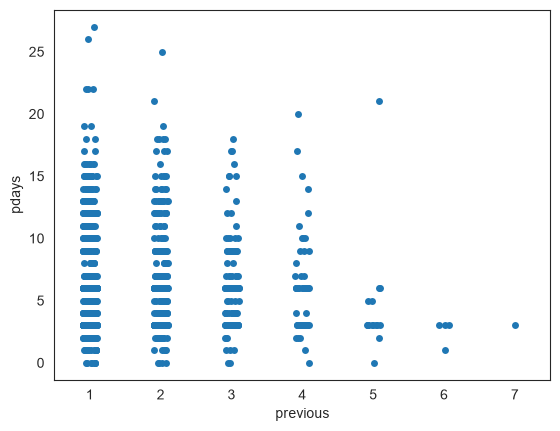

In [123]:
ax = sns.stripplot(data = df1[df1['pdays'] < 999], x = 'previous', y = 'pdays', jitter = True)
ax = ax

In [128]:
df1[(df1['previous'] > 0) & (df1['pdays'] < 999)]['poutcome'].value_counts(normalize = True)

poutcome
success    0.906271
failure    0.093729
Name: proportion, dtype: float64

In [127]:
df1[(df1['previous'] > 0) & (df1['pdays'] == 999)]['poutcome'].value_counts()

poutcome
failure    4110
Name: count, dtype: int64

- sempre que previous é 0, pdays será 999 e poutcome será nonexistent
- se previous for maior que 0 e pdays 999, o poutcome é sempre failure
- 9% do previous > 0 e pdays < 999 é failure

### Tem alguma categoria que se destaca mais por ter mais resultados positivos?

In [85]:
fig = grafico_yes_no(df1, "marital")
fig.show()

In [86]:
fig = grafico_yes_no(df1, "job")
fig.show()

In [87]:
fig = grafico_yes_no(df1, "education")
fig.show()

In [88]:
fig = grafico_yes_no(df1, "default")
fig.show()

In [89]:
fig = grafico_yes_no(df1, "housing")
fig.show()

In [90]:
fig = grafico_yes_no(df1, "loan")
fig.show()

In [91]:
fig = grafico_yes_no(df1, "contact")
fig.show()

In [92]:
fig = grafico_yes_no(df1, "day_of_week")
fig.show()

In [93]:
fig = grafico_yes_no(df1, "month")
fig.show()

In [94]:
fig = grafico_yes_no(df1, "poutcome")
fig.show()

Resultados: 
- Em relação a trabalho, estudantes e aposentados tendem a contratar mais
- Quem não tem crédito por padrão tambem tende a contratar mais
- Pelo celular as pessoas tendem a contratar mais do que pelo telefone
- Tambem contratam mais em março, setembro, outubro e dezembro, mas sao os meses com menos dados
- Quem já contratou antes tende a contratar novamente
- Não foram observadas diferenças significativas quanto a escolaridade, estado civil, financiamento imobiliário e empréstimo pessoal, dia da semana